# XGBoost Electrification Prediction with SHAP Interpretability

**Author:** Bouchra Daddaoui  
**Repository:** viirs-electrification-ml  

This notebook trains gradient-boosted tree models (XGBoost) to predict VIIRS nighttime light intensity
from geospatial covariates, then applies SHAP (SHapley Additive exPlanations) to:

1. Identify **which features drive electrification** most globally
2. Reveal **spatial heterogeneity** in feature importance via SHAP spatial maps
3. Quantify **prediction uncertainty** using bootstrap ensembles

This mirrors a common workflow in Earth observation research for interpretable geospatial ML.


In [1]:
import sys
sys.path.insert(0, '../scripts')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from ml_models import (
    train_xgboost, cross_validate_model,
    compute_shap_values, plot_shap_summary,
    plot_shap_dependence, spatial_shap_map,
    bootstrap_predictions, plot_uncertainty_map
)

FIGURES = Path('../figures')
FIGURES.mkdir(exist_ok=True)
np.random.seed(42)
print('Libraries loaded.')

Libraries loaded.


## 1. Generate Multi-Country Training Dataset

In [2]:
from shapely.geometry import box

def generate_panel(country, n, bbox, ntl_mean, ntl_std, seed):
    rng = np.random.default_rng(seed)
    minx, miny, maxx, maxy = bbox
    cols = int(np.sqrt(n))
    rows = n // cols
    xs = np.linspace(minx, maxx, cols + 1)
    ys = np.linspace(miny, maxy, rows + 1)
    geoms, tile_ids = [], []
    for i in range(rows):
        for j in range(cols):
            geoms.append(box(xs[j], ys[i], xs[j+1], ys[i+1]))
            tile_ids.append(f"{country}_{i:02d}_{j:02d}")
    n_act = len(geoms)
    centroids = np.array([[g.centroid.x, g.centroid.y] for g in geoms])
    dists = np.linalg.norm(centroids[:, None] - centroids[None, :], axis=-1)
    cov = ntl_std**2 * np.exp(-dists / (0.3 * (maxx - minx)))
    ntl = rng.multivariate_normal(np.full(n_act, ntl_mean), cov)
    ntl = np.clip(ntl, 0, None)
    pop_density    = rng.lognormal(mean=np.log(100), sigma=1.2, size=n_act)
    infra_density  = 0.4 * ntl / (ntl.max() + 1e-9) + 0.6 * rng.uniform(0, 1, n_act)
    dist_city      = rng.exponential(scale=50, size=n_act)
    hand_mean      = rng.lognormal(mean=np.log(5), sigma=0.8, size=n_act)
    gdp_proxy      = 0.6 * ntl + 0.4 * pop_density * 0.01 + rng.normal(0, 1, n_act)
    road_density   = 0.3 * infra_density + rng.uniform(0, 0.5, n_act)
    return gpd.GeoDataFrame({
        'tile_id': tile_ids, 'country': country,
        'ntl_mean': ntl, 'pop_density': pop_density,
        'infra_density': infra_density, 'dist_city_km': dist_city,
        'hand_mean_m': hand_mean, 'gdp_proxy': gdp_proxy,
        'road_density': road_density,
    }, geometry=geoms, crs='EPSG:4326')

configs = [
    dict(country='Brazil',  n=200, bbox=(-48,-23,-43,-18), ntl_mean=12.5, ntl_std=8.0,  seed=1),
    dict(country='China',   n=200, bbox=(116,29,122,33),   ntl_mean=28.3, ntl_std=14.0, seed=2),
    dict(country='Morocco', n=200, bbox=(-6,33,0,36),      ntl_mean=8.1,  ntl_std=5.5,  seed=3),
]
gdfs = {c['country']: generate_panel(**c) for c in configs}
all_gdf = gpd.GeoDataFrame(pd.concat(gdfs.values(), ignore_index=True), crs='EPSG:4326')
print(f"Total tiles: {len(all_gdf)} | Countries: {all_gdf.country.nunique()}")
all_gdf[['country','ntl_mean','pop_density','infra_density','dist_city_km','hand_mean_m']].describe()

Total tiles: 588 | Countries: 3


,ntl_mean,pop_density,infra_density,dist_city_km,hand_mean_m
count,588.000000,588.000000,588.000000,588.000000,588.000000
mean,13.657113,195.985975,0.450863,47.607297,7.188481
std,12.255412,344.336744,0.207857,46.974760,7.654905
min,0.000000,2.547501,0.002375,0.177129,0.455335
25%,4.658544,43.109239,0.302517,15.888883,2.807484
50%,10.147377,95.315795,0.445270,32.457949,5.237188
75%,19.060466,215.117941,0.596163,65.637215,8.873763
max,55.286399,4126.648869,0.921920,310.589143,100.559127


## 2. Cross-Validated XGBoost — All Countries

In [3]:
FEATURES = ['pop_density', 'infra_density', 'dist_city_km', 'hand_mean_m', 'gdp_proxy', 'road_density']
TARGET   = 'ntl_mean'

X = all_gdf[FEATURES].values
y = all_gdf[TARGET].values

cv_results = cross_validate_model(X, y, n_splits=5)
print("5-Fold Cross-Validation Results")
print(f"  RMSE per fold: {[round(v,3) for v in cv_results['rmse_scores']]}")
print(f"  R²   per fold: {[round(v,3) for v in cv_results['r2_scores']]}")
print(f"  Mean RMSE = {cv_results['mean_rmse']:.3f} ± {cv_results['std_rmse']:.3f}")
print(f"  Mean R²   = {cv_results['mean_r2']:.3f} ± {cv_results['std_r2']:.3f}")

5-Fold Cross-Validation Results
  RMSE per fold: [np.float64(2.176), np.float64(3.297), np.float64(2.378), np.float64(2.602), np.float64(2.384)]
  R²   per fold: [0.966, 0.931, 0.954, 0.952, 0.969]
  Mean RMSE = 2.567 ± 0.389
  Mean R²   = 0.954 ± 0.014


In [4]:
# Country-level CV (train on 2 countries, predict 3rd — leave-one-country-out)
print("\nLeave-One-Country-Out (LOCO) Evaluation")
print("-" * 45)
loco_results = {}

for test_country in ['Brazil', 'China', 'Morocco']:
    train_gdf = all_gdf[all_gdf.country != test_country]
    test_gdf  = all_gdf[all_gdf.country == test_country]
    
    X_tr = train_gdf[FEATURES].values
    y_tr = train_gdf[TARGET].values
    X_te = test_gdf[FEATURES].values
    y_te = test_gdf[TARGET].values
    
    from sklearn.metrics import mean_squared_error, r2_score
    model = train_xgboost(X_tr, y_tr)
    preds = model.predict(X_te)
    
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    r2   = r2_score(y_te, preds)
    loco_results[test_country] = {'RMSE': rmse, 'R2': r2}
    print(f"  Test: {test_country:8s} | RMSE = {rmse:.3f} | R² = {r2:.3f}")


Leave-One-Country-Out (LOCO) Evaluation
---------------------------------------------


  Test: Brazil   | RMSE = 2.607 | R² = 0.782
  Test: China    | RMSE = 12.089 | R² = 0.029


  Test: Morocco  | RMSE = 3.664 | R² = 0.105


## 3. SHAP Feature Importance — Global

In [5]:
# Train final model on all data
final_model = train_xgboost(X, y)
shap_values, explainer = compute_shap_values(final_model, X, FEATURES)

print("Mean absolute SHAP values (global feature importance):")
mean_abs_shap = np.abs(shap_values).mean(axis=0)
importance_df = pd.DataFrame({
    'Feature': FEATURES,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False)
print(importance_df.to_string(index=False))

Mean absolute SHAP values (global feature importance):
      Feature  Mean |SHAP|
    gdp_proxy     8.859417
  pop_density     0.794598
infra_density     0.783069
 road_density     0.254857
 dist_city_km     0.227019
  hand_mean_m     0.197025


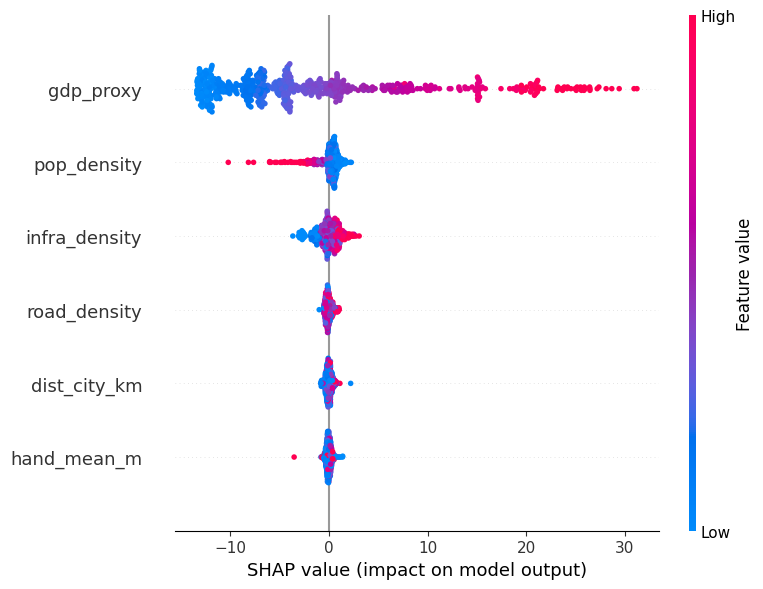

Saved → figures/shap_summary.png


In [6]:
fig = plot_shap_summary(
    shap_values, X, FEATURES,
    max_display=6,
    save_path=str(FIGURES / 'shap_summary.png')
)
plt.show()
print('Saved → figures/shap_summary.png')

## 4. SHAP Dependence Plots — Key Features

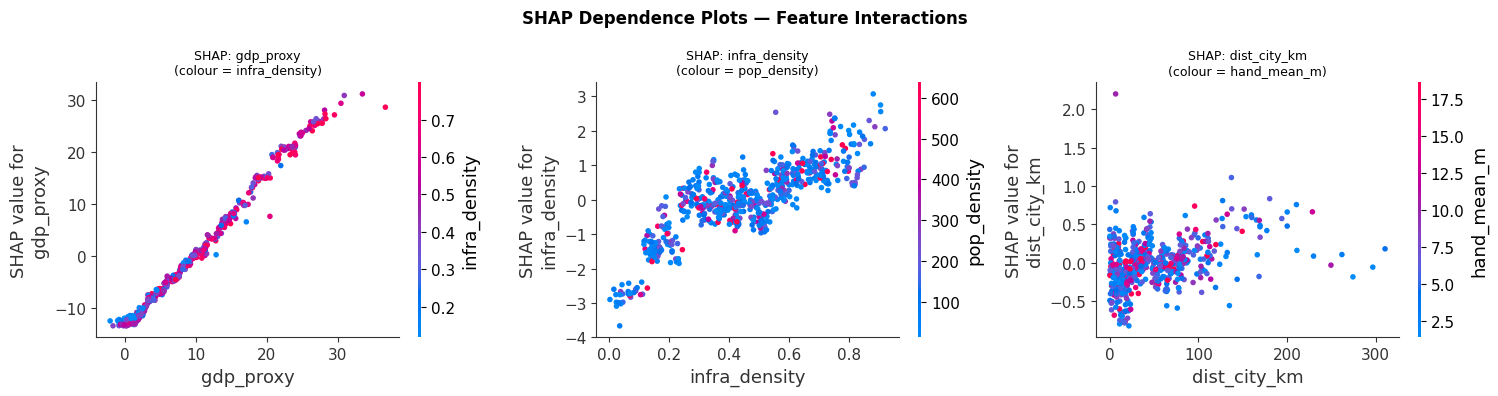

Saved → figures/shap_dependence.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pairs = [
    ('gdp_proxy',     'infra_density'),
    ('infra_density', 'pop_density'),
    ('dist_city_km',  'hand_mean_m'),
]

import shap
for ax, (feat, interaction) in zip(axes, pairs):
    feat_idx = FEATURES.index(feat)
    int_idx  = FEATURES.index(interaction)
    shap.dependence_plot(
        feat_idx, shap_values, X,
        feature_names=FEATURES,
        interaction_index=int_idx,
        ax=ax, show=False
    )
    ax.set_title(f'SHAP: {feat}\n(colour = {interaction})', fontsize=9)

fig.suptitle('SHAP Dependence Plots — Feature Interactions', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'shap_dependence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/shap_dependence.png')

## 5. Spatial SHAP Maps — Where Does Each Feature Drive Predictions?

Red tiles = the feature **increases** predicted NTL there.  
Blue tiles = the feature **decreases** predicted NTL there.

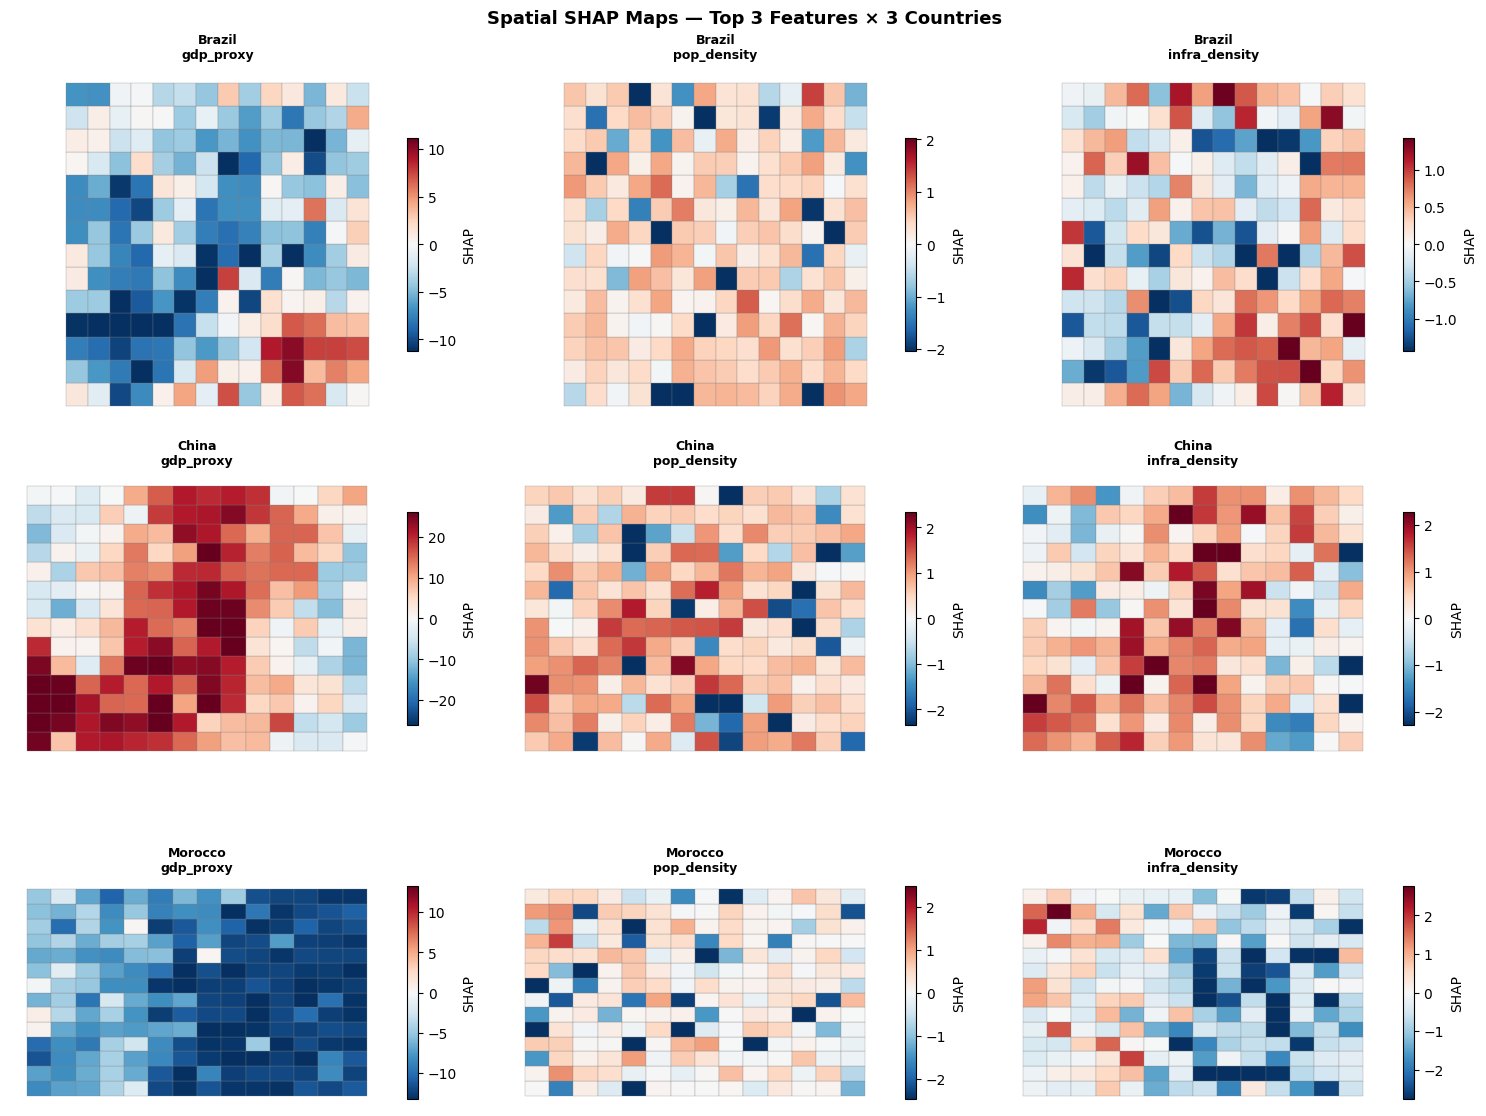

Saved → figures/spatial_shap_maps.png


In [8]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

top_features = importance_df['Feature'].head(3).tolist()
country_list = ['Brazil', 'China', 'Morocco']

for row_idx, country in enumerate(country_list):
    gdf_c = all_gdf[all_gdf.country == country].reset_index(drop=True)
    X_c   = gdf_c[FEATURES].values
    sv_c, _ = compute_shap_values(final_model, X_c, FEATURES)
    
    for col_idx, feat in enumerate(top_features):
        ax = axes[row_idx, col_idx]
        feat_idx = FEATURES.index(feat)
        gdf_c['shap_val'] = sv_c[:, feat_idx]
        vmax = gdf_c['shap_val'].abs().quantile(0.95)
        gdf_c.plot(column='shap_val', cmap='RdBu_r', vmin=-vmax, vmax=vmax,
                   edgecolor='grey', linewidth=0.2, legend=True,
                   legend_kwds={'shrink': 0.6, 'label': 'SHAP'}, ax=ax)
        ax.set_title(f'{country}\n{feat}', fontsize=9, fontweight='bold')
        ax.set_axis_off()

fig.suptitle('Spatial SHAP Maps — Top 3 Features × 3 Countries', fontsize=13, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'spatial_shap_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/spatial_shap_maps.png')

## 6. Bootstrap Uncertainty Quantification

We train 200 XGBoost models on bootstrap resamples and compute 90% prediction intervals.
Tiles with wide CIs represent **uncertain predictions** — typically marginal or transition zones.

In [9]:
print('Running bootstrap ensemble (200 models)...')
bs_results = bootstrap_predictions(X, y, X, n_bootstrap=200, ci=0.90)
print(f'Done. Mean prediction: {bs_results["mean_pred"].mean():.2f}')
print(f'Mean CI width: {(bs_results["upper"] - bs_results["lower"]).mean():.2f}')

ci_width = bs_results['upper'] - bs_results['lower']
print(f'\nPercentile breakdown of CI width:')
for pct in [25, 50, 75, 90, 95]:
    print(f'  p{pct}: {np.percentile(ci_width, pct):.2f}')

Running bootstrap ensemble (200 models)...


Done. Mean prediction: 13.63
Mean CI width: 3.42

Percentile breakdown of CI width:
  p25: 2.31
  p50: 3.00
  p75: 4.03
  p90: 5.38
  p95: 6.42


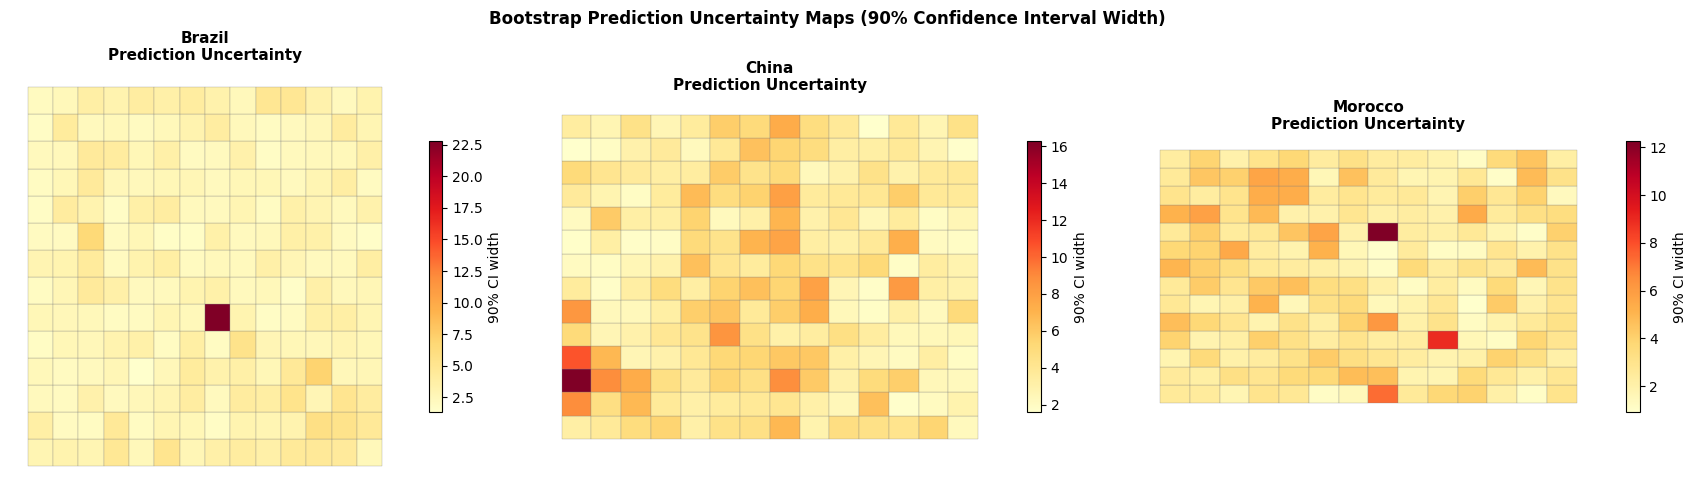

Saved → figures/bootstrap_uncertainty_maps.png


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, country in zip(axes, country_list):
    mask = all_gdf.country == country
    gdf_c = all_gdf[mask].copy().reset_index(drop=True)
    gdf_c['ci_width'] = ci_width[mask.values]
    
    gdf_c.plot(column='ci_width', cmap='YlOrRd', edgecolor='grey', linewidth=0.2,
               legend=True, legend_kwds={'label': '90% CI width', 'shrink': 0.65}, ax=ax)
    ax.set_title(f'{country}\nPrediction Uncertainty', fontsize=11, fontweight='bold')
    ax.set_axis_off()

fig.suptitle('Bootstrap Prediction Uncertainty Maps (90% Confidence Interval Width)', fontsize=12, fontweight='bold')
fig.tight_layout()
fig.savefig(FIGURES / 'bootstrap_uncertainty_maps.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved → figures/bootstrap_uncertainty_maps.png')

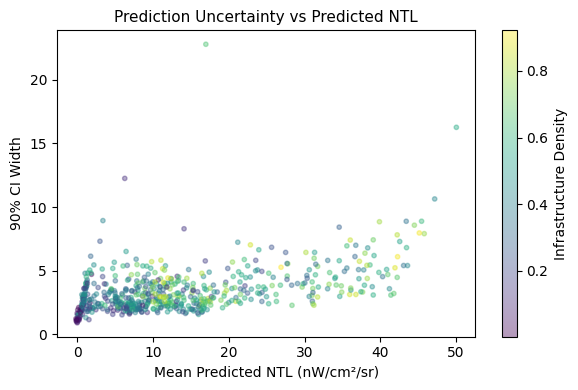

In [11]:
# Scatter: predicted NTL vs CI width
fig, ax = plt.subplots(figsize=(6, 4))
sc = ax.scatter(bs_results['mean_pred'], ci_width,
                c=all_gdf['infra_density'].values, cmap='viridis',
                alpha=0.4, s=10)
plt.colorbar(sc, ax=ax, label='Infrastructure Density')
ax.set_xlabel('Mean Predicted NTL (nW/cm²/sr)')
ax.set_ylabel('90% CI Width')
ax.set_title('Prediction Uncertainty vs Predicted NTL', fontsize=11)
fig.tight_layout()
fig.savefig(FIGURES / 'uncertainty_vs_prediction.png', dpi=150, bbox_inches='tight')
plt.show()